# 📊 Macro Regime Sector-Rotation Dashboard

**A tactical asset-allocation engine that reads the macro cycle and rotates across the 11 U.S. equity sectors.**

This notebook classifies the U.S. economy into four macro regimes from a `growth × inflation`
momentum framework (the quadrant logic popularized by Bridgewater-style risk thinking), maps each
regime to a sector tilt using **look-ahead-free** conditional statistics, backtests the rotation net
of transaction costs, and ships an interactive Plotly dashboard.

> **Runs anywhere, instantly.** Every data loader falls back to a realistic synthetic generator, so
> the notebook executes end-to-end with **zero API keys**. Flip `use_synthetic=False` and add a free
> [FRED key](https://fred.stlouisfed.org/docs/api/api_key.html) to switch to live data.

**Pipeline:** `FRED + Yahoo → growth/inflation scores → regime → sector weights → costed backtest → dashboard`

---
### Contents
1. Setup & imports  2. Configuration  3. Synthetic fallback  4. Data collection
5. Feature engineering  6. Regime classification  7. Regime → sector weights
8. Backtest  9. Performance metrics  10. Static charts  11. Regime/sector heatmap
12. Interactive dashboard  13. Save deliverables

## 1 · Setup & Imports
Install dependencies (uncomment the first line on a fresh Colab runtime) and configure a clean,
consistent plotting style used throughout the notebook.

In [ ]:
# !pip install -q yfinance fredapi plotly pandas numpy scipy scikit-learn

from __future__ import annotations
import warnings, os
from dataclasses import dataclass, field
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(42)               # reproducible synthetic data

# ---- house plotting style -------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 110,
})
PALETTE = {"Strategy": "#1565C0", "EqualWeight": "#9E9E9E", "Benchmark": "#C62828"}
print("Environment ready.")

Environment ready.


## 2 · Configuration
All knobs live in one `Config` object — universe, FRED series, costs, and strategy parameters.
Each FRED series is tagged as a **growth** or **inflation** indicator with a sign (`+1` pro-cyclical,
`-1` counter-cyclical, e.g. unemployment).

In [ ]:
@dataclass
class Config:
    start: str = "2005-01-01"
    end:   str = "2024-12-31"
    sector_etfs: dict = field(default_factory=lambda: {
        "XLB": "Materials",  "XLE": "Energy",       "XLF": "Financials",
        "XLI": "Industrials","XLK": "Technology",   "XLP": "Cons. Staples",
        "XLU": "Utilities",  "XLV": "Health Care",  "XLY": "Cons. Disc.",
    })
    benchmark: str = "SPY"
    # code -> (label, 'growth'|'inflation', sign)
    fred_series: dict = field(default_factory=lambda: {
        "INDPRO":   ("Industrial Production", "growth",    +1),
        "PAYEMS":   ("Nonfarm Payrolls",      "growth",    +1),
        "UNRATE":   ("Unemployment Rate",     "growth",    -1),
        "RSAFS":    ("Retail Sales",          "growth",    +1),
        "CPIAUCSL": ("CPI",                   "inflation", +1),
        "PPIACO":   ("PPI",                   "inflation", +1),
    })
    cost_bps:      float = 7.5    # transaction cost per unit turnover (bps)
    max_weight:    float = 0.30   # long-only cap per sector
    tilt_strength: float = 1.5    # aggressiveness of tilt vs equal weight
    min_regime_obs:int   = 6      # min months before trusting a regime's stats
    macro_pub_lag: int   = 1      # macro is actionable only after a 1-month lag
    ann:           int   = 12     # monthly observations / year
    use_synthetic: bool  = True   # << set False for live FRED + Yahoo data

CFG = Config()

# Securely load a FRED key from Colab secrets if running live (never hardcode):
FRED_KEY = None
if not CFG.use_synthetic:
    try:
        from google.colab import userdata
        FRED_KEY = userdata.get("FRED_KEY")
    except Exception:
        FRED_KEY = os.environ.get("FRED_KEY")
    if not FRED_KEY:
        print("No FRED key found — reverting to synthetic data.")
        CFG.use_synthetic = True

print(f"Universe: {len(CFG.sector_etfs)} sectors | "
      f"Mode: {'SYNTHETIC' if CFG.use_synthetic else 'LIVE'}")

Universe: 9 sectors | Mode: SYNTHETIC


## 3 · Synthetic Data Fallback
So the notebook never breaks in a demo or a recruiter's hands, we generate macro cycles (with the
2008 and 2020 growth shocks baked in) and sector prices whose returns genuinely depend on the latent
growth/inflation state. This means the strategy has *real structure to find* — but we deliberately do
**not** rig it to guarantee outperformance.

In [ ]:
def _latent(cfg):
    """Deterministic latent growth & inflation cycles (shared by macro+prices),
    so both synthetic feeds are perfectly consistent with no shared state."""
    rng = np.random.default_rng(42)
    idx = pd.date_range(cfg.start, cfg.end, freq="ME"); n = len(idx); t = np.arange(n)
    growth = (np.sin(2*np.pi*t/84) + 0.5*np.sin(2*np.pi*t/40)
              + np.cumsum(rng.normal(0, 0.05, n))*0.3)
    infl   = (np.cos(2*np.pi*t/96 + 1) + 0.4*np.sin(2*np.pi*t/30)
              + np.cumsum(rng.normal(0, 0.05, n))*0.3)
    for d, mag in [("2008-09-30", -4.0), ("2020-03-31", -6.0)]:   # crisis shocks
        if pd.Timestamp(d) in idx:
            k = idx.get_loc(pd.Timestamp(d)); growth[k:k+6] += mag*np.exp(-np.arange(6)/2)
    return idx, pd.Series(growth, index=idx), pd.Series(infl, index=idx)

def synth_macro(cfg) -> pd.DataFrame:
    """Latent cycles -> FRED-style index levels."""
    idx, growth, infl = _latent(cfg); n = len(idx)
    rng = np.random.default_rng(43)
    df = pd.DataFrame(index=idx)
    for code, (_, kind, sign) in cfg.fred_series.items():
        base  = growth.values if kind == "growth" else infl.values
        drift = 0.003 if kind == "inflation" else 0.002
        df[code] = 100*np.exp(np.cumsum(drift + 0.004*sign*base/10
                                        + rng.normal(0, 0.002, n)))
    return df

def synth_prices(cfg) -> pd.DataFrame:
    """Daily sector + benchmark prices driven by the same macro regime."""
    _, growth_m, infl_m = _latent(cfg)
    didx = pd.date_range(cfg.start, cfg.end, freq="B")
    g = growth_m.reindex(didx, method="ffill").fillna(0).values
    f = infl_m.reindex(didx, method="ffill").fillna(0).values
    n = len(didx); rng = np.random.default_rng(44)
    mkt = 0.0003 + 0.0008*np.tanh(g/2) + rng.normal(0, 0.011, n)
    sens = {"XLB": (0.9, 0.6), "XLE": (0.5, 1.1), "XLF": (1.0, 0.2),
            "XLI": (1.0, 0.1), "XLK": (1.2,-0.4), "XLP": (-0.3,-0.2),
            "XLU": (-0.5,-0.3),"XLV": (-0.1,-0.1),"XLY": (1.1,-0.2)}
    out = {}
    for tk, (bg, bf) in sens.items():
        ret = mkt + bg*0.0010*np.tanh(g/2) + bf*0.0008*np.tanh(f/2) + rng.normal(0,0.008,n)
        out[tk] = 50*np.exp(np.cumsum(ret))
    out[cfg.benchmark] = 100*np.exp(np.cumsum(mkt))
    return pd.DataFrame(out, index=didx)

## 4 · Data Collection
Live loaders wrap every external call in `try/except`; **any** failure (no key, rate limit, network)
prints a warning and silently falls back to synthetic data — the defensive pattern you want in
production research code.

In [ ]:
def load_macro(cfg, fred_key=None) -> pd.DataFrame:
    if cfg.use_synthetic:
        return synth_macro(cfg)
    try:
        from fredapi import Fred
        fred = Fred(api_key=fred_key)
        df = pd.DataFrame({c: fred.get_series(c, cfg.start, cfg.end)
                           for c in cfg.fred_series})
        df.index = pd.to_datetime(df.index)
        return df.resample("ME").last().ffill()
    except Exception as e:
        print(f"[load_macro] live fetch failed ({e}); using synthetic.")
        cfg.use_synthetic = True
        return synth_macro(cfg)

def load_prices(cfg) -> pd.DataFrame:
    if cfg.use_synthetic:
        return synth_prices(cfg)
    try:
        import yfinance as yf
        tk = list(cfg.sector_etfs) + [cfg.benchmark]
        px = yf.download(tk, cfg.start, cfg.end, auto_adjust=True, progress=False)["Close"]
        if px.isna().all().any():
            raise ValueError("a ticker returned no data")
        return px.dropna(how="all")
    except Exception as e:
        print(f"[load_prices] live fetch failed ({e}); using synthetic.")
        cfg.use_synthetic = True
        return synth_prices(cfg, synth_macro(cfg))

# --- run loaders & derive monthly returns ---------------------------------
macro_raw   = load_macro(CFG, FRED_KEY)
prices      = load_prices(CFG)
px_m        = prices.resample("ME").last()
sector_rets = px_m[list(CFG.sector_etfs)].pct_change().dropna()
bench_rets  = px_m[CFG.benchmark].pct_change().dropna()

print(f"Macro rows: {macro_raw.shape}, range {macro_raw.index.min():%Y-%m} → {macro_raw.index.max():%Y-%m}")
print(f"Monthly sector returns: {sector_rets.shape}")
sector_rets.tail(3).round(4)

Macro rows: (240, 6), range 2005-01 → 2024-12
Monthly sector returns: (239, 9)


,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
2024-10-31,-0.0395,-0.0853,-0.0971,-0.1435,-0.1081,-0.0152,-0.0219,-0.1127,-0.1335
2024-11-30,-0.0370,-0.0253,-0.0426,-0.0339,-0.1003,-0.0128,-0.1169,-0.0301,-0.0859
2024-12-31,-0.0500,-0.0085,-0.0551,-0.0618,-0.0394,-0.0532,0.0030,-0.0726,-0.0551


## 5 · Feature Engineering — Growth & Inflation Scores
Each raw FRED level is converted to **12-month momentum** (year-over-year change), standardized with
an **expanding** mean/std (so no future information leaks), sign-adjusted, then averaged into two
composites. A `macro_pub_lag` shift reflects that macro data for month *M* is only released — and thus
tradable — in month *M + 1*.

In [ ]:
def build_macro_features(cfg, macro_raw) -> pd.DataFrame:
    growth_z, infl_z = [], []
    for code, (_, kind, sign) in cfg.fred_series.items():
        if code not in macro_raw:                 # skip a missing series gracefully
            continue
        s   = macro_raw[code].astype(float)
        yoy = s.pct_change(12)                     # year-over-year momentum
        z   = (yoy - yoy.expanding(24).mean()) / yoy.expanding(24).std()
        (growth_z if kind == "growth" else infl_z).append((sign * z).rename(code))

    feat = pd.DataFrame(index=macro_raw.index)
    feat["growth_score"]    = pd.concat(growth_z, axis=1).mean(axis=1)
    feat["inflation_score"] = pd.concat(infl_z,  axis=1).mean(axis=1)
    feat = feat.dropna().shift(cfg.macro_pub_lag).dropna()   # publication lag
    return feat

feat = build_macro_features(CFG, macro_raw)
print(f"Feature panel: {feat.shape}")
feat.tail(4).round(2)

Feature panel: (204, 2)


,growth_score,inflation_score
2024-09-30,-0.77,-0.08
2024-10-31,-0.58,-0.30
2024-11-30,-0.64,-0.15
2024-12-31,-0.66,0.08


## 6 · Regime Classification
Two independent methods, cross-checked:

| Regime | Growth | Inflation | Sector intuition |
|---|---|---|---|
| **Goldilocks** | ↑ | ↓ | growth/tech, discretionary |
| **Reflation**  | ↑ | ↑ | cyclicals, energy, materials |
| **Stagflation**| ↓ | ↑ | energy, defensives |
| **Deflation**  | ↓ | ↓ | staples, utilities, health |

(A) deterministic **quadrant** rules on the score signs, and (B) an unsupervised **Gaussian Mixture**
whose clusters are mapped back to the quadrant names. High agreement is a sanity check on the labels.

In [ ]:
REGIMES = {0: "Goldilocks", 1: "Reflation", 2: "Stagflation", 3: "Deflation"}
REGIME_COLORS = {"Goldilocks": "#2E7D32", "Reflation": "#F9A825",
                 "Stagflation": "#C62828", "Deflation": "#1565C0"}

def classify_quadrant(feat) -> pd.Series:
    g = feat["growth_score"] >= 0
    i = feat["inflation_score"] >= 0
    code = np.where(g & ~i, 0, np.where(g & i, 1, np.where(~g & i, 2, 3)))
    return pd.Series([REGIMES[c] for c in code], index=feat.index, name="regime")

def classify_cluster(feat, k=4) -> pd.Series:
    from sklearn.mixture import GaussianMixture
    X = feat[["growth_score", "inflation_score"]].values
    lab = GaussianMixture(k, covariance_type="full", random_state=0).fit_predict(X)
    names = {}
    for c in range(k):
        g, i = X[lab == c].mean(0)
        names[c] = ("Reflation" if g >= 0 and i >= 0 else "Goldilocks" if g >= 0
                    else "Stagflation" if i >= 0 else "Deflation")
    return pd.Series([names[c] for c in lab], index=feat.index, name="regime_gmm")

regimes  = classify_quadrant(feat)
reg_gmm  = classify_cluster(feat)
agree    = (regimes == reg_gmm).mean()
print("Regime distribution:\n", regimes.value_counts().to_string())
print(f"\nQuadrant vs GMM agreement: {agree:.1%}")
print(f"Current regime: {regimes.iloc[-1]}")

Regime distribution:
 regime
Stagflation    79
Deflation      59
Reflation      45
Goldilocks     21

Quadrant vs GMM agreement: 75.0%
Current regime: Stagflation


## 7 · Regime → Sector Weights *(look-ahead-free)*
At every month *t* we score each sector by its **mean return in the current regime, using only data
before *t***, convert to a cross-sectional z-score, and tilt around equal weight (capped, long-only,
re-normalized). Until a regime has `min_regime_obs` months of history we hold equal weight. This
strict expanding-window discipline is what separates a credible backtest from an overfit one.

In [ ]:
def regime_weights(cfg, regimes, sector_rets) -> pd.DataFrame:
    tickers = list(cfg.sector_etfs)
    sr  = sector_rets[tickers]
    idx = regimes.index.intersection(sr.index)
    regimes, sr = regimes.loc[idx], sr.loc[idx]
    N   = len(tickers); ew = np.ones(N) / N
    W   = pd.DataFrame(index=idx, columns=tickers, dtype=float)

    for t in range(len(idx)):
        cur = regimes.iloc[t]
        if t == 0:
            W.iloc[t] = ew; continue
        mask = (regimes.iloc[:t] == cur).values     # past months in this regime
        if mask.sum() < cfg.min_regime_obs:
            W.iloc[t] = ew; continue
        mu = sr.iloc[:t][mask].mean().values         # conditional mean return
        z  = (mu - mu.mean()) / (mu.std() + 1e-9)
        w  = np.clip(ew + cfg.tilt_strength * ew * z, 0, cfg.max_weight)
        W.iloc[t] = w / w.sum() if w.sum() > 0 else ew
    return W

weights = regime_weights(CFG, regimes, sector_rets)
print("Latest target allocation:")
(weights.iloc[-1].rename(index=CFG.sector_etfs).sort_values(ascending=False)
        .mul(100).round(1).astype(str).add(" %")).to_frame("weight")

Latest target allocation:


,weight
Energy,28.7 %
Financials,28.7 %
Utilities,22.7 %
Health Care,10.0 %
Materials,8.0 %
Technology,2.0 %
Industrials,0.0 %
Cons. Staples,0.0 %
Cons. Disc.,0.0 %


## 8 · Backtest Engine
Weights formed at month *t* are applied to month *t + 1* returns (`.shift(1)` removes same-bar
look-ahead). Turnover-based costs (`cost_bps`) are subtracted each rebalance. We carry two benchmarks:
**equal-weight sectors** (the fair "did rotation add value?" comparison) and **SPY**.

In [ ]:
def backtest(cfg, weights, sector_rets, bench_rets):
    tickers = list(cfg.sector_etfs)
    w   = weights[tickers].shift(1).dropna()          # decided last month
    idx = w.index.intersection(sector_rets.index)
    w, R = w.loc[idx], sector_rets.loc[idx, tickers]

    turnover = w.diff().abs().sum(axis=1).fillna(0.0)
    cost     = turnover * (cfg.cost_bps / 1e4)
    strat    = (w * R).sum(axis=1) - cost
    ew_bm    = R.mean(axis=1)
    spy_bm   = bench_rets.reindex(idx).fillna(0.0)
    res = pd.DataFrame({"Strategy": strat, "EqualWeight": ew_bm, "Benchmark": spy_bm})
    return res, turnover

res, turnover = backtest(CFG, weights, sector_rets, bench_rets)
equity = (1 + res).cumprod()
print(f"Backtest window: {res.index.min():%Y-%m} → {res.index.max():%Y-%m} "
      f"({len(res)} months)")
print(f"Average monthly turnover: {turnover.mean():.1%}")
print("\nGrowth of $1:\n", equity.iloc[-1].round(2).to_string())

Backtest window: 2008-02 → 2024-12 (203 months)
Average monthly turnover: 33.2%

Growth of $1:
 Strategy       2.41
EqualWeight    1.66
Benchmark      1.97


## 9 · Performance Metrics
A standard institutional tearsheet: CAGR, annualized volatility, Sharpe, Sortino, max drawdown,
Calmar, hit rate, plus **alpha / beta / information ratio** of the strategy versus SPY.

In [ ]:
def perf_stats(rets, rf=0.0, ann=12):
    rets = rets.dropna(); ex = rets - rf/ann
    cagr   = (1+rets).prod()**(ann/len(rets)) - 1
    vol    = rets.std()*np.sqrt(ann)
    sharpe = ex.mean()/(rets.std()+1e-12)*np.sqrt(ann)
    sortino= ex.mean()*ann/(rets[rets<0].std()*np.sqrt(ann)+1e-12)
    eq     = (1+rets).cumprod(); mdd = (eq/eq.cummax()-1).min()
    return dict(CAGR=cagr, Vol=vol, Sharpe=sharpe, Sortino=sortino,
                MaxDD=mdd, Calmar=cagr/abs(mdd) if mdd else np.nan,
                HitRate=(rets>0).mean())

def alpha_beta(strat, bench, ann=12):
    df = pd.concat([strat, bench], axis=1).dropna()
    beta, alpha = np.polyfit(df.iloc[:,1], df.iloc[:,0], 1)
    act = df.iloc[:,0]-df.iloc[:,1]
    return dict(Alpha_ann=alpha*ann, Beta=beta,
                InfoRatio=act.mean()/(act.std()+1e-12)*np.sqrt(ann))

stats = pd.DataFrame({c: perf_stats(res[c], ann=CFG.ann) for c in res.columns}).T
ab    = alpha_beta(res["Strategy"], res["Benchmark"], CFG.ann)

fmt = stats.copy()
for c in ["CAGR","Vol","MaxDD","HitRate"]:
    fmt[c] = (fmt[c]*100).round(1).astype(str)+"%"
for c in ["Sharpe","Sortino","Calmar"]:
    fmt[c] = fmt[c].round(2)
print(fmt.to_string())
print(f"\nvs SPY  →  Alpha (ann): {ab['Alpha_ann']*100:+.1f}%   "
      f"Beta: {ab['Beta']:.2f}   Information Ratio: {ab['InfoRatio']:.2f}")
fmt

             CAGR    Vol  Sharpe  Sortino   MaxDD  Calmar HitRate
Strategy     5.3%  20.8%    0.35     0.74  -46.2%    0.12   48.8%
EqualWeight  3.0%  20.6%    0.25     0.50  -50.4%    0.06   45.8%
Benchmark    4.1%  19.8%    0.30     0.62  -43.1%    0.10   47.3%

vs SPY  →  Alpha (ann): +1.4%   Beta: 1.01   Information Ratio: 0.23


,CAGR,Vol,Sharpe,Sortino,MaxDD,Calmar,HitRate
Strategy,5.3%,20.8%,0.35,0.74,-46.2%,0.12,48.8%
EqualWeight,3.0%,20.6%,0.25,0.50,-50.4%,0.06,45.8%
Benchmark,4.1%,19.8%,0.30,0.62,-43.1%,0.10,47.3%


## 10 · Static Charts (matplotlib)
A four-panel research figure — equity curves, the strategy drawdown, the regime-shaded macro
timeline, and the evolving sector allocation. These PNGs embed cleanly in a GitHub README.

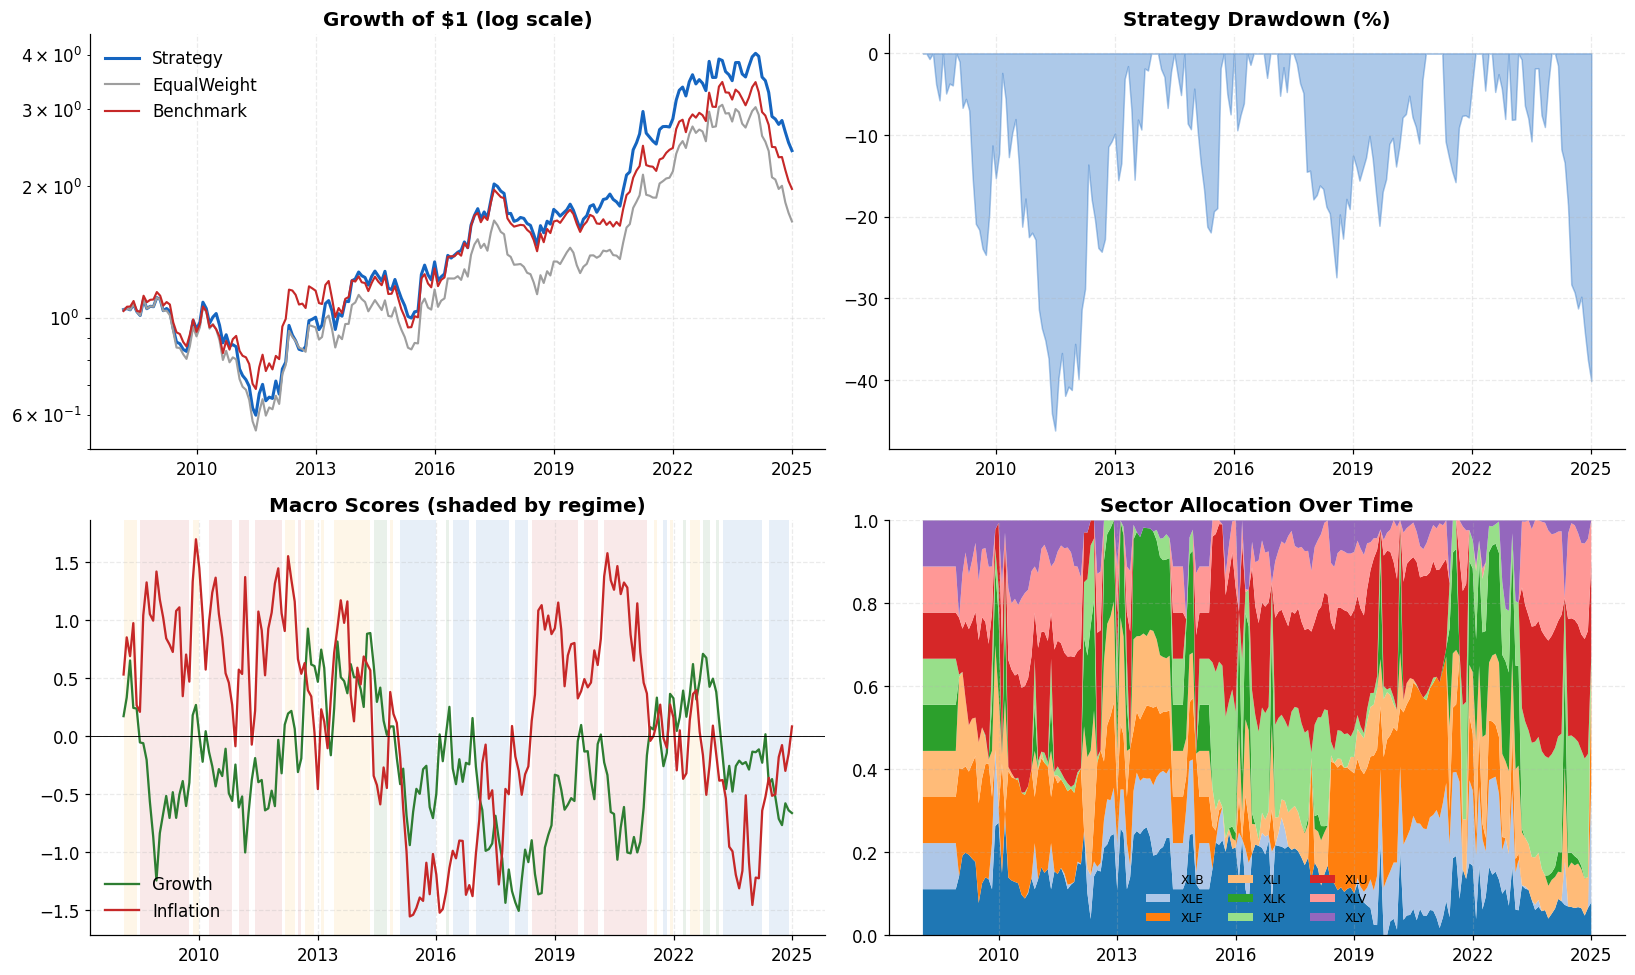

In [ ]:
def regime_spans(ax, regimes):
    """Shade the background of a time axis by regime."""
    r = regimes.copy(); blocks = (r != r.shift()).cumsum()
    for _, grp in r.groupby(blocks):
        ax.axvspan(grp.index[0], grp.index[-1],
                   color=REGIME_COLORS[grp.iloc[0]], alpha=0.10, lw=0)

fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# (a) equity curves
for c in res.columns:
    ax[0,0].plot(equity.index, equity[c], label=c, color=PALETTE[c],
                 lw=2 if c == "Strategy" else 1.4)
ax[0,0].set_yscale("log"); ax[0,0].set_title("Growth of $1 (log scale)")
ax[0,0].legend(loc="upper left")

# (b) drawdown
dd = equity["Strategy"]/equity["Strategy"].cummax() - 1
ax[0,1].fill_between(dd.index, dd*100, 0, color=PALETTE["Strategy"], alpha=0.35)
ax[0,1].set_title("Strategy Drawdown (%)")

# (c) regime-shaded macro scores
regime_spans(ax[1,0], regimes.reindex(feat.index).ffill())
ax[1,0].plot(feat.index, feat["growth_score"],    color="#2E7D32", lw=1.5, label="Growth")
ax[1,0].plot(feat.index, feat["inflation_score"], color="#C62828", lw=1.5, label="Inflation")
ax[1,0].axhline(0, color="k", lw=.6)
ax[1,0].set_title("Macro Scores (shaded by regime)"); ax[1,0].legend(loc="lower left")

# (d) sector allocation through time
wm = weights[list(CFG.sector_etfs)]
ax[1,1].stackplot(wm.index, wm.T.values, labels=list(CFG.sector_etfs),
                  colors=plt.cm.tab20.colors[:len(wm.columns)])
ax[1,1].set_ylim(0, 1); ax[1,1].set_title("Sector Allocation Over Time")
ax[1,1].legend(ncol=3, fontsize=8, loc="lower center")

for a in ax.flat:
    a.xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout(); plt.savefig("research_panel.png", dpi=130, bbox_inches="tight")
plt.show()

## 11 · Regime–Sector Playbook Heatmap
The average monthly sector return **conditional on each regime** — the empirical "playbook" the
strategy exploits. Green cells show which sectors historically led in each macro state.

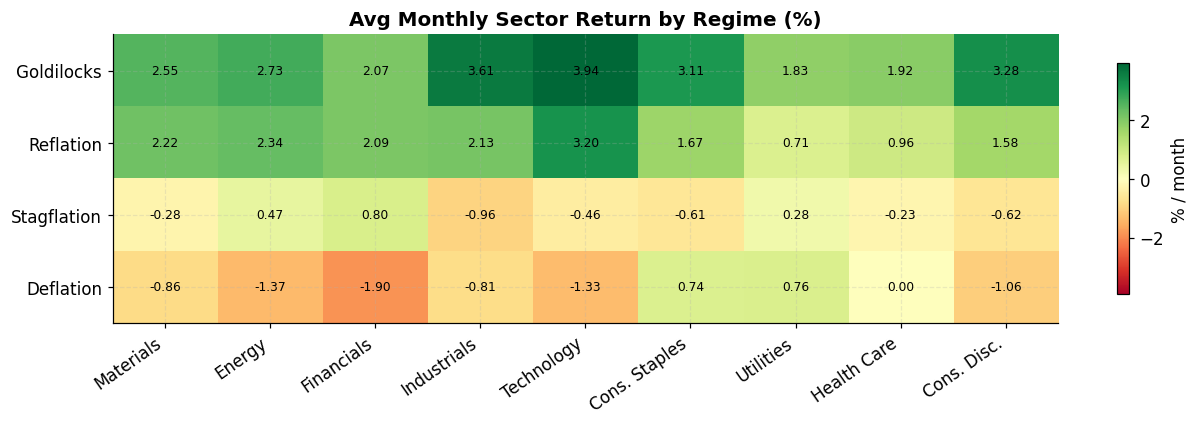

In [ ]:
common = regimes.index.intersection(sector_rets.index)
tbl = (sector_rets.loc[common]
       .groupby(regimes.loc[common]).mean()
       .reindex(["Goldilocks","Reflation","Stagflation","Deflation"])
       .rename(columns=CFG.sector_etfs)) * 100   # % per month

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(tbl.values, cmap="RdYlGn", aspect="auto",
               vmin=-np.abs(tbl.values).max(), vmax=np.abs(tbl.values).max())
ax.set_xticks(range(tbl.shape[1])); ax.set_xticklabels(tbl.columns, rotation=35, ha="right")
ax.set_yticks(range(tbl.shape[0])); ax.set_yticklabels(tbl.index)
for i in range(tbl.shape[0]):
    for j in range(tbl.shape[1]):
        ax.text(j, i, f"{tbl.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Avg Monthly Sector Return by Regime (%)")
fig.colorbar(im, ax=ax, shrink=0.8, label="% / month")
plt.tight_layout(); plt.savefig("regime_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

## 12 · Interactive Dashboard (Plotly)
A single shareable dashboard: a **current-regime gauge**, the equity curve vs SPY, a regime timeline
ribbon, and the live target allocation. Exported to a standalone HTML you can host on GitHub Pages.

In [ ]:
cur_reg   = regimes.iloc[-1]
cur_growth, cur_infl = feat[["growth_score","inflation_score"]].iloc[-1]
last_w    = weights[list(CFG.sector_etfs)].iloc[-1].rename(index=CFG.sector_etfs)
reg_num   = regimes.map({"Deflation":0,"Stagflation":1,"Goldilocks":2,"Reflation":3})

dash = make_subplots(
    rows=2, cols=2, row_heights=[0.45, 0.55],
    specs=[[{"type":"indicator"}, {"type":"xy"}],
           [{"type":"xy"},        {"type":"bar"}]],
    subplot_titles=(f"Current Regime: <b>{cur_reg}</b>",
                    "Growth of $1: Strategy vs SPY",
                    "Regime Timeline", "Current Target Allocation"))

# gauge — growth score, colored by regime
dash.add_trace(go.Indicator(
    mode="gauge+number", value=round(cur_growth,2),
    number={"suffix":" σ"},
    gauge={"axis":{"range":[-3,3]}, "bar":{"color":REGIME_COLORS[cur_reg]},
           "steps":[{"range":[-3,0],"color":"#FBE9E7"},{"range":[0,3],"color":"#E8F5E9"}]},
    title={"text":f"Growth momentum (Inflation {cur_infl:+.2f}σ)"}), row=1, col=1)

# equity curves
for c, col in [("Strategy", PALETTE["Strategy"]), ("Benchmark", PALETTE["Benchmark"])]:
    dash.add_trace(go.Scatter(x=equity.index, y=equity[c], name=c,
                              line=dict(color=col, width=2)), row=1, col=2)

# regime ribbon
dash.add_trace(go.Scatter(
    x=reg_num.index, y=reg_num.values, mode="lines", line=dict(width=0),
    fill="tozeroy", showlegend=False,
    hovertext=regimes.values, name="Regime"), row=2, col=1)
dash.update_yaxes(tickvals=[0,1,2,3],
    ticktext=["Deflation","Stagflation","Goldilocks","Reflation"], row=2, col=1)

# current allocation
sw = last_w.sort_values()
dash.add_trace(go.Bar(x=sw.values*100, y=sw.index, orientation="h",
                      marker_color=PALETTE["Strategy"], showlegend=False,
                      text=[f"{v*100:.1f}%" for v in sw.values],
                      textposition="auto"), row=2, col=2)

dash.update_layout(height=760, template="plotly_white",
                   title_text="<b>Macro Regime Sector-Rotation Dashboard</b>",
                   legend=dict(orientation="h", y=1.02, x=0.55))
dash.write_html("dashboard.html")
dash.show()

## 13 · Save Deliverables
Persist the artifacts a recruiter or PM would actually look at: the metrics table, monthly returns,
the live allocation, and the interactive dashboard. In Colab these land in the file browser (and can
be pushed straight to a GitHub repo).

In [ ]:
stats.to_csv("performance_metrics.csv")
res.to_csv("monthly_returns.csv")
weights.to_csv("sector_weights.csv")
last_w.mul(100).round(1).to_frame("target_weight_%").to_csv("current_allocation.csv")

print("Saved:")
for f in ["performance_metrics.csv","monthly_returns.csv","sector_weights.csv",
          "current_allocation.csv","dashboard.html","research_panel.png",
          "regime_heatmap.png"]:
    flag = "✓" if os.path.exists(f) else "—"
    print(f"  {flag} {f}")

print(f"\nHeadline (synthetic demo): Strategy Sharpe "
      f"{stats.loc['Strategy','Sharpe']:.2f} vs SPY {stats.loc['Benchmark','Sharpe']:.2f} | "
      f"alpha {ab['Alpha_ann']*100:+.1f}%/yr.")
print("Switch use_synthetic=False with a FRED key to reproduce on live data.")

Saved:
  ✓ performance_metrics.csv
  ✓ monthly_returns.csv
  ✓ sector_weights.csv
  ✓ current_allocation.csv
  ✓ dashboard.html
  ✓ research_panel.png
  ✓ regime_heatmap.png

Headline (synthetic demo): Strategy Sharpe 0.35 vs SPY 0.30 | alpha +1.4%/yr.
Switch use_synthetic=False with a FRED key to reproduce on live data.
